In [1]:
!pip install faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 62.5 MB/s eta 0:00:00


In [2]:
import os
import sys
import json
import time
import random
import math
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from transformers import CLIPModel, CLIPProcessor

import faiss


DATASET_ROOT = Path("/kaggle/input/datasets/khanhngnguynl/inshop")

IMAGE_ROOT = DATASET_ROOT
PARTITION_FILE = DATASET_ROOT / "Eval" / "list_eval_partition.txt"

OUTPUT_DIR = Path("/kaggle/working/visfit_inshop_finetune")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
EMBEDDINGS_DIR = OUTPUT_DIR / "embeddings"
RESULTS_DIR = OUTPUT_DIR / "results"
PLOTS_DIR = OUTPUT_DIR / "plots"
LOGS_DIR = OUTPUT_DIR / "logs"

for d in [OUTPUT_DIR, CHECKPOINT_DIR, EMBEDDINGS_DIR, RESULTS_DIR, PLOTS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("DATASET_ROOT   :", DATASET_ROOT, "| exists:", DATASET_ROOT.exists())
print("PARTITION_FILE :", PARTITION_FILE, "| exists:", PARTITION_FILE.exists())
print("OUTPUT_DIR      :", OUTPUT_DIR)
for d in [CHECKPOINT_DIR, EMBEDDINGS_DIR, RESULTS_DIR, PLOTS_DIR, LOGS_DIR]:
    print("  -", d)

# =====================================================================
# TRAINING CONFIG
# =====================================================================
CONFIG = {
    "SEED": 42,
    "EPOCHS": 8,
    "P": 8,                 # số item_id mỗi batch
    "K": 4,                 # số ảnh mỗi item_id
    "BATCH_SIZE": 32,       # P * K
    "LR_BACKBONE": 1e-5,
    "LR_HEAD": 1e-4,
    "WEIGHT_DECAY": 1e-4,
    "TEMPERATURE": 0.07,
    "GRAD_CLIP": 1.0,
    "EARLY_STOP_PATIENCE": 3,
    "VAL_ITEM_RATIO": 0.1,
    "NUM_WORKERS": 0,
    "MODEL_NAME": "patrickjohncyh/fashion-clip",
    "N_UNFROZEN_VISION_BLOCKS": 2,
    "KS": (1, 5, 10, 20),
}

assert CONFIG["P"] * CONFIG["K"] == CONFIG["BATCH_SIZE"], "P * K phải bằng BATCH_SIZE"

with open(LOGS_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)
print("\nĐã lưu config:", LOGS_DIR / "config.json")
print(json.dumps(CONFIG, indent=2))

DATASET_ROOT   : /kaggle/input/datasets/khanhngnguynl/inshop | exists: True
PARTITION_FILE : /kaggle/input/datasets/khanhngnguynl/inshop/Eval/list_eval_partition.txt | exists: True
OUTPUT_DIR      : /kaggle/working/visfit_inshop_finetune
  - /kaggle/working/visfit_inshop_finetune/checkpoints
  - /kaggle/working/visfit_inshop_finetune/embeddings
  - /kaggle/working/visfit_inshop_finetune/results
  - /kaggle/working/visfit_inshop_finetune/plots
  - /kaggle/working/visfit_inshop_finetune/logs

Đã lưu config: /kaggle/working/visfit_inshop_finetune/logs/config.json
{
  "SEED": 42,
  "EPOCHS": 8,
  "P": 8,
  "K": 4,
  "BATCH_SIZE": 32,
  "LR_BACKBONE": 1e-05,
  "LR_HEAD": 0.0001,
  "WEIGHT_DECAY": 0.0001,
  "TEMPERATURE": 0.07,
  "GRAD_CLIP": 1.0,
  "EARLY_STOP_PATIENCE": 3,
  "VAL_ITEM_RATIO": 0.1,
  "NUM_WORKERS": 0,
  "MODEL_NAME": "patrickjohncyh/fashion-clip",
  "N_UNFROZEN_VISION_BLOCKS": 2,
  "KS": [
    1,
    5,
    10,
    20
  ]
}


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CONFIG["SEED"])

# cudnn deterministic: an toàn cho reproducibility, có thể chậm hơn một chút
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("[WARNING] Không có GPU - training sẽ rất chậm.")

Device: cuda
GPU: Tesla T4
CUDA version: 12.8


In [4]:
def load_inshop_partition(path):
    if not path.exists():
        raise FileNotFoundError(f"Không tìm thấy list_eval_partition.txt tại: {path}")

    try:
        with open(path, "r", encoding="utf-8") as f:
            lines = f.readlines()
    except UnicodeDecodeError:
        with open(path, "r", encoding="latin-1") as f:
            lines = f.readlines()

    if len(lines) < 2:
        raise ValueError("File list_eval_partition.txt có định dạng không hợp lệ (quá ít dòng).")

    declared_count = None
    try:
        declared_count = int(lines[0].strip())
    except ValueError:
        print("[WARNING] Không parse được số lượng ảnh khai báo ở dòng đầu.")

    header_line = lines[1].strip().split()
    data_lines = lines[2:]

    records = []
    n_bad_lines = 0
    for line in data_lines:
        parts = line.strip().split()
        if len(parts) != 3:
            n_bad_lines += 1
            continue
        records.append(parts)

    if n_bad_lines > 0:
        print(f"[WARNING] {n_bad_lines} dòng bị loại do sai định dạng (không đúng 3 cột).")

    columns = header_line if len(header_line) == 3 else ["image_name", "item_id", "evaluation_status"]
    df = pd.DataFrame(records, columns=columns)

    before = len(df)
    df = df.dropna().drop_duplicates(subset=["image_name"])
    after = len(df)
    if after < before:
        print(f"[WARNING] {before - after} dòng bị loại do NaN hoặc duplicate image_name.")

    df = df.reset_index(drop=True)

    print("=" * 50)
    print("PARTITION FILE CHECK")
    print("=" * 50)
    print(f"Declared count (dòng 1)  : {declared_count}")
    print(f"Actual parsed rows       : {len(df)}")
    print(f"Train    : {(df['evaluation_status'] == 'train').sum()}")
    print(f"Query    : {(df['evaluation_status'] == 'query').sum()}")
    print(f"Gallery  : {(df['evaluation_status'] == 'gallery').sum()}")
    print()

    for split in ["train", "query", "gallery"]:
        n_unique_items = df.loc[df["evaluation_status"] == split, "item_id"].nunique()
        print(f"Unique items ({split}): {n_unique_items}")

    dup_image_name = df["image_name"].duplicated().sum()
    null_values = df.isna().sum().sum()
    print(f"\nDuplicate image_name : {dup_image_name}")
    print(f"Null values total    : {null_values}")

    # --- Kiểm tra item overlap giữa các partition (README nói KHÔNG overlap) ---
    train_items = set(df.loc[df["evaluation_status"] == "train", "item_id"])
    query_items = set(df.loc[df["evaluation_status"] == "query", "item_id"])
    gallery_items = set(df.loc[df["evaluation_status"] == "gallery", "item_id"])

    overlap_train_query = train_items & query_items
    overlap_train_gallery = train_items & gallery_items
    overlap_query_gallery_same_split_check = query_items & gallery_items  # expected: có thể trùng (đúng ý retrieval)

    print("\n--- Item overlap check ---")
    print(f"train ∩ query   : {len(overlap_train_query)}")
    print(f"train ∩ gallery : {len(overlap_train_gallery)}")
    print(f"query ∩ gallery : {len(overlap_query_gallery_same_split_check)} "
          f"(BÌNH THƯỜNG - retrieval item thường có ảnh ở cả query & gallery)")

    if len(overlap_train_query) > 0 or len(overlap_train_gallery) > 0:
        print("\n" + "!" * 60)
        print("[WARNING LỚN] Phát hiện item_id bị OVERLAP giữa TRAIN và QUERY/GALLERY!")
        print("Điều này VI PHẠM giả định của official README (items không overlap).")
        print("Cần kiểm tra lại dataset trước khi tiếp tục training.")
        print("!" * 60)
    else:
        print("\nKhông có overlap giữa train và query/gallery - khớp với official README.")

    print("=" * 50)

    return df


partition_df = load_inshop_partition(PARTITION_FILE)
partition_df.head()

PARTITION FILE CHECK
Declared count (dòng 1)  : 52712
Actual parsed rows       : 52712
Train    : 25882
Query    : 14218
Gallery  : 12612

Unique items (train): 3997
Unique items (query): 3985
Unique items (gallery): 3985

Duplicate image_name : 0
Null values total    : 0

--- Item overlap check ---
train ∩ query   : 0
train ∩ gallery : 0
query ∩ gallery : 3985 (BÌNH THƯỜNG - retrieval item thường có ảnh ở cả query & gallery)

Không có overlap giữa train và query/gallery - khớp với official README.


,image_name,item_id,evaluation_status
0,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,id_00000002,train
1,img/WOMEN/Dresses/id_00000002/02_2_side.jpg,id_00000002,train
2,img/WOMEN/Dresses/id_00000002/02_4_full.jpg,id_00000002,train
3,img/WOMEN/Dresses/id_00000002/02_7_additional.jpg,id_00000002,train
4,img/WOMEN/Skirts/id_00000003/02_1_front.jpg,id_00000003,train


In [5]:
def print_dataset_statistics(df):
    print("=" * 50)
    print("DATASET STATISTICS")
    print("=" * 50)
    print(f"Total images   : {len(df)}")
    for split in ["train", "query", "gallery"]:
        n_images = (df["evaluation_status"] == split).sum()
        n_items = df.loc[df["evaluation_status"] == split, "item_id"].nunique()
        print(f"{split.capitalize():8s} images: {n_images:6d}  |  unique items: {n_items}")

    print()
    train_df = df[df["evaluation_status"] == "train"]
    images_per_item = train_df.groupby("item_id").size()

    print("--- Images per item (TRAIN) ---")
    print(f"Min    : {images_per_item.min()}")
    print(f"Max    : {images_per_item.max()}")
    print(f"Mean   : {images_per_item.mean():.4f}")
    print(f"Median : {images_per_item.median()}")

    n_items_ge_2 = (images_per_item >= 2).sum()
    print(f"\nSố item có >= 2 ảnh: {n_items_ge_2} / {len(images_per_item)} "
          f"({n_items_ge_2 / len(images_per_item):.2%})")
    print("(Item chỉ có 1 ảnh sẽ không đóng góp positive pair thực sự trong batch trừ khi "
          "sampling-with-replacement tạo ra bản sao của cùng 1 ảnh.)")
    print("=" * 50)

    return images_per_item


images_per_item_train = print_dataset_statistics(partition_df)

DATASET STATISTICS
Total images   : 52712
Train    images:  25882  |  unique items: 3997
Query    images:  14218  |  unique items: 3985
Gallery  images:  12612  |  unique items: 3985

--- Images per item (TRAIN) ---
Min    : 1
Max    : 162
Mean   : 6.4754
Median : 4.0

Số item có >= 2 ảnh: 3985 / 3997 (99.70%)
(Item chỉ có 1 ảnh sẽ không đóng góp positive pair thực sự trong batch trừ khi sampling-with-replacement tạo ra bản sao của cùng 1 ảnh.)


In [6]:
def split_train_val_by_item(train_df, val_ratio, seed):
    """
    Split theo item_id, KHÔNG theo ảnh. Một item_id chỉ thuộc 1 split.
    """
    unique_items = sorted(train_df["item_id"].unique())
    rng = np.random.RandomState(seed)
    shuffled_items = rng.permutation(unique_items)

    n_val_items = int(len(shuffled_items) * val_ratio)
    val_items = set(shuffled_items[:n_val_items])
    train_items = set(shuffled_items[n_val_items:])

    assert len(train_items & val_items) == 0, "Item bị lẫn giữa train_sub và val_sub!"

    train_sub_df = train_df[train_df["item_id"].isin(train_items)].reset_index(drop=True)
    val_sub_df = train_df[train_df["item_id"].isin(val_items)].reset_index(drop=True)

    print("=" * 50)
    print("TRAIN / VAL ITEM-LEVEL SPLIT")
    print("=" * 50)
    print(f"Total train items : {len(unique_items)}")
    print(f"train_sub items   : {len(train_items)} ({len(train_items)/len(unique_items):.2%})")
    print(f"val_sub items     : {len(val_items)} ({len(val_items)/len(unique_items):.2%})")
    print(f"train_sub images  : {len(train_sub_df)}")
    print(f"val_sub images    : {len(val_sub_df)}")
    print("=" * 50)

    return train_sub_df, val_sub_df


train_full_df = partition_df[partition_df["evaluation_status"] == "train"].reset_index(drop=True)
query_df = partition_df[partition_df["evaluation_status"] == "query"].reset_index(drop=True)
gallery_df = partition_df[partition_df["evaluation_status"] == "gallery"].reset_index(drop=True)

train_sub_df, val_sub_df = split_train_val_by_item(
    train_full_df, CONFIG["VAL_ITEM_RATIO"], CONFIG["SEED"]
)

print(f"\nQuery official images : {len(query_df)}")
print(f"Gallery official images  : {len(gallery_df)}")

TRAIN / VAL ITEM-LEVEL SPLIT
Total train items : 3997
train_sub items   : 3598 (90.02%)
val_sub items     : 399 (9.98%)
train_sub images  : 23266
val_sub images    : 2616

Query official images : 14218
Gallery official images  : 12612


In [7]:
def resolve_image_path(image_root, image_name):
    """
    Thử vài cách ghép path phổ biến vì cấu trúc thư mục extract có thể khác nhau
    tuỳ nguồn dataset trên Kaggle. In cảnh báo nếu không tìm thấy.
    """
    candidates = [
        image_root / image_name,
        image_root / "Img" / image_name,
        image_root / Path(*Path(image_name).parts[1:]) if Path(image_name).parts[0] == "img" else None,
    ]
    for c in candidates:
        if c is not None and c.exists():
            return c
    return image_root / image_name  # fallback, sẽ raise lỗi rõ ràng khi Image.open thất bại


class InShopDataset(Dataset):
    """
    Trả về (image_tensor, label, image_name, item_id).
    label = integer-encoded item_id nếu item_to_label được cung cấp, ngược lại -1
    (dùng cho query/gallery dataset chỉ để extract embedding, không cần label).
    """

    def __init__(self, df, image_root, processor, item_to_label=None):
        self.df = df.reset_index(drop=True)
        self.image_root = Path(image_root)
        self.processor = processor
        self.item_to_label = item_to_label

        if item_to_label is not None:
            self.labels = np.array([item_to_label[item_id] for item_id in self.df["item_id"]])
        else:
            self.labels = np.full(len(self.df), -1)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = row["image_name"]
        item_id = row["item_id"]

        image_path = resolve_image_path(self.image_root, image_name)
        image = Image.open(image_path).convert("RGB")

        pixel_values = self.processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

        label = int(self.labels[idx])
        return pixel_values, label, image_name, item_id


def build_item_to_label(df):
    unique_items = sorted(df["item_id"].unique())
    return {item_id: i for i, item_id in enumerate(unique_items)}


# Dataset/label mapping sẽ được khởi tạo ở Cell 8 sau khi có processor.

In [8]:
class PKSampler(Sampler):
    """
    Mỗi batch: P item_id, K ảnh/item_id. Nếu 1 item không đủ K ảnh,
    sampling-with-replacement được phép (lấy lại ảnh đã dùng trong cùng batch).
    """

    def __init__(self, labels, P, K, seed=42):
        self.labels = np.asarray(labels)
        self.P = P
        self.K = K
        self.batch_size = P * K
        self.rng = np.random.RandomState(seed)

        self.label_to_indices = defaultdict(list)
        for idx, label in enumerate(self.labels):
            self.label_to_indices[label].append(idx)

        self.unique_labels = list(self.label_to_indices.keys())
        self.n_batches = len(self.unique_labels) // self.P
        if self.n_batches == 0:
            raise ValueError(
                f"Không đủ item_id ({len(self.unique_labels)}) để tạo batch với P={self.P}."
            )

    def __iter__(self):
        shuffled_labels = self.rng.permutation(self.unique_labels)

        for batch_idx in range(self.n_batches):
            batch_labels = shuffled_labels[batch_idx * self.P: (batch_idx + 1) * self.P]
            batch_indices = []
            for label in batch_labels:
                indices = self.label_to_indices[label]
                if len(indices) >= self.K:
                    chosen = self.rng.choice(indices, size=self.K, replace=False)
                else:
                    chosen = self.rng.choice(indices, size=self.K, replace=True)
                batch_indices.extend(chosen.tolist())
            yield batch_indices

    def __len__(self):
        return self.n_batches


def sanity_check_pk_sampler(sampler, labels):
    print("=" * 50)
    print("PK SAMPLER SANITY CHECK")
    print("=" * 50)
    first_batch = next(iter(sampler))
    batch_labels = labels[first_batch]
    unique_ids, counts = np.unique(batch_labels, return_counts=True)

    print(f"Batch size          : {len(first_batch)}")
    print(f"Number unique identities : {len(unique_ids)} (expected {sampler.P})")
    print(f"Images per identity : {dict(zip(unique_ids.tolist(), counts.tolist()))}")
    print(f"Tất cả count đều = K ({sampler.K})? "
          f"{'YES' if all(c == sampler.K for c in counts) else 'NO'}")
    print("=" * 50)

In [9]:
def load_fashion_clip(model_name, device):
    model = CLIPModel.from_pretrained(model_name)
    processor = CLIPProcessor.from_pretrained(model_name)
    model.to(device)
    return model, processor


pretrained_model, processor = load_fashion_clip(CONFIG["MODEL_NAME"], device)
print(f"Đã load model: {CONFIG['MODEL_NAME']}")
print(f"Vision embed dim: {pretrained_model.config.projection_dim}")

# Dataset instances (giờ mới tạo được vì cần `processor`)
item_to_label_train = build_item_to_label(train_sub_df)

train_dataset = InShopDataset(train_sub_df, IMAGE_ROOT, processor, item_to_label=item_to_label_train)
val_dataset = InShopDataset(val_sub_df, IMAGE_ROOT, processor, item_to_label=build_item_to_label(val_sub_df))
query_dataset = InShopDataset(query_df, IMAGE_ROOT, processor, item_to_label=None)
gallery_dataset = InShopDataset(gallery_df, IMAGE_ROOT, processor, item_to_label=None)

print(f"\ntrain_dataset : {len(train_dataset)} samples, {len(item_to_label_train)} unique items")
print(f"val_dataset   : {len(val_dataset)} samples")
print(f"query_dataset : {len(query_dataset)} samples")
print(f"gallery_dataset: {len(gallery_dataset)} samples")

train_sampler = PKSampler(train_dataset.labels, CONFIG["P"], CONFIG["K"], seed=CONFIG["SEED"])
val_sampler = PKSampler(val_dataset.labels, CONFIG["P"], CONFIG["K"], seed=CONFIG["SEED"])

sanity_check_pk_sampler(train_sampler, train_dataset.labels)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Đã load model: patrickjohncyh/fashion-clip
Vision embed dim: 512

train_dataset : 23266 samples, 3598 unique items
val_dataset   : 2616 samples
query_dataset : 14218 samples
gallery_dataset: 12612 samples
PK SAMPLER SANITY CHECK
Batch size          : 32
Number unique identities : 8 (expected 8)
Images per identity : {802: 4, 871: 4, 969: 4, 1334: 4, 1356: 4, 1825: 4, 2882: 4, 3412: 4}
Tất cả count đều = K (4)? YES


In [10]:
def inspect_model_modules(model, max_depth=3):
    """In module tree tới độ sâu max_depth để xác định tên module chính xác."""
    print("=" * 50)
    print("MODEL MODULE TREE (top-level)")
    print("=" * 50)
    for name, module in model.named_children():
        print(f"{name}: {type(module).__name__}")
        if hasattr(module, "named_children"):
            for sub_name, sub_module in module.named_children():
                print(f"  {sub_name}: {type(sub_module).__name__}")


inspect_model_modules(pretrained_model)


def freeze_and_unfreeze(model, n_unfrozen_vision_blocks):
    """
    Freeze toàn bộ model, sau đó unfreeze:
    - N block cuối của vision_model.encoder.layers
    - visual_projection (final projection layer)

    Nếu không tìm thấy đúng tên module (architecture khác), raise lỗi rõ ràng
    thay vì âm thầm unfreeze sai hoặc unfreeze toàn bộ.
    """
    for param in model.parameters():
        param.requires_grad = False

    trainable_module_names = []

    if not hasattr(model, "vision_model") or not hasattr(model.vision_model, "encoder"):
        raise AttributeError(
            "Không tìm thấy model.vision_model.encoder - kiểm tra lại architecture bằng "
            "inspect_model_modules() trước khi unfreeze."
        )

    vision_layers = model.vision_model.encoder.layers
    n_layers = len(vision_layers)
    unfreeze_from = max(0, n_layers - n_unfrozen_vision_blocks)

    for i in range(unfreeze_from, n_layers):
        for param in vision_layers[i].parameters():
            param.requires_grad = True
        trainable_module_names.append(f"vision_model.encoder.layers[{i}]")

    if not hasattr(model, "visual_projection"):
        raise AttributeError("Không tìm thấy model.visual_projection - kiểm tra lại architecture.")

    for param in model.visual_projection.parameters():
        param.requires_grad = True
    trainable_module_names.append("visual_projection")

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params

    print("=" * 50)
    print("FREEZE / UNFREEZE SUMMARY")
    print("=" * 50)
    print(f"Total parameters     : {total_params:,}")
    print(f"Trainable parameters : {trainable_params:,} ({trainable_params/total_params:.2%})")
    print(f"Frozen parameters    : {frozen_params:,}")
    print(f"\nTrainable modules:")
    for name in trainable_module_names:
        print(f"  - {name}")
    print("=" * 50)

    return trainable_module_names


trainable_module_names = freeze_and_unfreeze(pretrained_model, CONFIG["N_UNFROZEN_VISION_BLOCKS"])

MODEL MODULE TREE (top-level)
text_model: CLIPTextTransformer
  embeddings: CLIPTextEmbeddings
  encoder: CLIPEncoder
  final_layer_norm: LayerNorm
vision_model: CLIPVisionTransformer
  embeddings: CLIPVisionEmbeddings
  pre_layrnorm: LayerNorm
  encoder: CLIPEncoder
  post_layernorm: LayerNorm
visual_projection: Linear
text_projection: Linear
FREEZE / UNFREEZE SUMMARY
Total parameters     : 151,277,313
Trainable parameters : 14,568,960 (9.63%)
Frozen parameters    : 136,708,353

Trainable modules:
  - vision_model.encoder.layers[10]
  - vision_model.encoder.layers[11]
  - visual_projection


In [11]:
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss (Khosla et al., 2020).
    Input: embeddings đã L2-normalize (B, D), labels (B,)
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):
        device = embeddings.device
        batch_size = embeddings.shape[0]

        labels = labels.contiguous().view(-1, 1)
        mask_positive = torch.eq(labels, labels.T).float().to(device)  # (B, B), 1 nếu cùng label

        similarity = torch.matmul(embeddings, embeddings.T) / self.temperature  # (B, B)

        # Numerical stability: subtract max
        sim_max, _ = torch.max(similarity, dim=1, keepdim=True)
        logits = similarity - sim_max.detach()

        # Exclude self-pair khỏi cả positive mask và denominator
        self_mask = torch.eye(batch_size, dtype=torch.bool, device=device)
        mask_positive = mask_positive.masked_fill(self_mask, 0)

        exp_logits = torch.exp(logits).masked_fill(self_mask, 0)
        log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

        n_positives_per_sample = mask_positive.sum(dim=1)
        # Sample nào không có positive nào trong batch (item chỉ xuất hiện 1 lần) -> bỏ qua
        valid_mask = n_positives_per_sample > 0

        if valid_mask.sum() == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)

        mean_log_prob_pos = (mask_positive * log_prob).sum(dim=1)[valid_mask] / n_positives_per_sample[valid_mask]
        loss = -mean_log_prob_pos.mean()

        return loss


# --- Test trên dummy tensor trước khi training ---
def test_supcon_loss():
    torch.manual_seed(0)
    dummy_emb = F.normalize(torch.randn(8, 16), dim=1)
    dummy_labels = torch.tensor([0, 0, 1, 1, 2, 2, 3, 3])

    loss_fn = SupConLoss(temperature=CONFIG["TEMPERATURE"])
    loss_value = loss_fn(dummy_emb, dummy_labels)

    print("=" * 50)
    print("SUPCON LOSS - DUMMY TEST")
    print("=" * 50)
    print(f"Dummy loss value: {loss_value.item():.6f}")
    assert not torch.isnan(loss_value), "Loss là NaN trên dummy test!"
    assert not torch.isinf(loss_value), "Loss là Inf trên dummy test!"
    print("Loss hợp lệ (không NaN/Inf).")
    print("=" * 50)


test_supcon_loss()
supcon_loss_fn = SupConLoss(temperature=CONFIG["TEMPERATURE"])

SUPCON LOSS - DUMMY TEST
Dummy loss value: 5.330426
Loss hợp lệ (không NaN/Inf).


In [12]:
def build_optimizer_and_scheduler(model, config, n_training_steps):
    backbone_params = []
    head_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "visual_projection" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)

    param_groups = [
        {"params": backbone_params, "lr": config["LR_BACKBONE"]},
        {"params": head_params, "lr": config["LR_HEAD"]},
    ]

    optimizer = torch.optim.AdamW(param_groups, weight_decay=config["WEIGHT_DECAY"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_training_steps)

    print("=" * 50)
    print("OPTIMIZER & SCHEDULER")
    print("=" * 50)
    print(f"Backbone params: {sum(p.numel() for p in backbone_params):,} (lr={config['LR_BACKBONE']})")
    print(f"Head params    : {sum(p.numel() for p in head_params):,} (lr={config['LR_HEAD']})")
    print(f"Weight decay   : {config['WEIGHT_DECAY']}")
    print(f"Scheduler      : CosineAnnealingLR (T_max={n_training_steps})")
    print("=" * 50)

    return optimizer, scheduler


n_training_steps = CONFIG["EPOCHS"] * len(train_sampler)
optimizer, scheduler = build_optimizer_and_scheduler(pretrained_model, CONFIG, n_training_steps)

OPTIMIZER & SCHEDULER
Backbone params: 14,175,744 (lr=1e-05)
Head params    : 393,216 (lr=0.0001)
Weight decay   : 0.0001
Scheduler      : CosineAnnealingLR (T_max=3592)


In [13]:
def encode_images(model, pixel_values):

    output = model.get_image_features(
        pixel_values=pixel_values
    )

    if torch.is_tensor(output):
        embedding = output

    elif hasattr(output, "image_embeds") and output.image_embeds is not None:
        embedding = output.image_embeds

    elif hasattr(output, "pooler_output") and output.pooler_output is not None:
        embedding = output.pooler_output

    elif hasattr(output, "last_hidden_state") and output.last_hidden_state is not None:
        embedding = output.last_hidden_state[:, 0, :]

    else:
        raise TypeError(
            f"Unsupported output type: {type(output)}"
        )

    if embedding.shape[-1] != 512:

        if hasattr(model, "visual_projection"):
            embedding = model.visual_projection(
                embedding
            )

        elif hasattr(model, "vision_projection"):
            embedding = model.vision_projection(
                embedding
            )

        else:
            raise ValueError(
                f"Embedding dim = {embedding.shape[-1]}, "
                "expected 512, but projection layer not found."
            )

    embedding = F.normalize(
        embedding,
        p=2,
        dim=-1
    )

    assert torch.is_tensor(embedding)

    assert embedding.ndim == 2

    assert embedding.shape[-1] == 512, (
        f"Expected (B, 512), got {embedding.shape}"
    )

    return embedding


def train_one_epoch(model, loader, loss_fn, optimizer, scheduler, scaler, device, grad_clip):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for pixel_values, labels, _, _ in tqdm(loader, desc="Train", leave=False):
        pixel_values = pixel_values.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):
            embeddings = encode_images(model, pixel_values)
            loss = loss_fn(embeddings, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], grad_clip
        )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def validate_one_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    n_batches = 0

    for pixel_values, labels, _, _ in tqdm(loader, desc="Val", leave=False):
        pixel_values = pixel_values.to(device)
        labels = labels.to(device)

        embeddings = encode_images(model, pixel_values)
        loss = loss_fn(embeddings, labels)

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def extract_embeddings(model, dataset, device, batch_size=32, num_workers=2, desc="Extracting"):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    model.eval()
    all_embeddings = []
    all_image_names = []
    all_item_ids = []

    for pixel_values, _, image_names, item_ids in tqdm(loader, desc=desc):
        pixel_values = pixel_values.to(device)
        embeddings = encode_images(model, pixel_values)
        all_embeddings.append(embeddings.cpu().numpy().astype(np.float32))
        all_image_names.extend(image_names)
        all_item_ids.extend(item_ids)

    embeddings_array = np.concatenate(all_embeddings, axis=0)
    metadata_df = pd.DataFrame({"image_name": all_image_names, "item_id": all_item_ids})

    return embeddings_array, metadata_df

In [14]:
def build_official_ground_truth(query_df, gallery_df):
    """
    positive gallery cho mỗi query = tất cả gallery image có cùng item_id
    (Ground truth chính thức, dựa trực tiếp trên official item_id).
    """
    positive_dict = {}
    gallery_by_item = gallery_df.groupby("item_id")["image_name"].apply(set).to_dict()

    n_query_without_positive = 0
    for _, row in query_df.iterrows():
        item_id = row["item_id"]
        image_name = row["image_name"]
        positives = gallery_by_item.get(item_id, set())
        if len(positives) == 0:
            n_query_without_positive += 1
        positive_dict[image_name] = positives

    counts = [len(v) for v in positive_dict.values() if len(v) > 0]

    print("=" * 50)
    print("OFFICIAL GROUND TRUTH")
    print("=" * 50)
    print(f"Number queries : {len(query_df)}")
    print(f"Number gallery : {len(gallery_df)}")
    if counts:
        print(f"Min positives/query  : {min(counts)}")
        print(f"Max positives/query  : {max(counts)}")
        print(f"Mean positives/query : {np.mean(counts):.4f}")

    if n_query_without_positive > 0:
        print(f"\n[WARNING] {n_query_without_positive} query KHÔNG có positive gallery. "
              f"KHÔNG silently drop - các query này sẽ được giữ nhưng AP/Recall = 0 khi evaluate, "
              f"hoặc cần lọc tường minh trước khi tính metric (xem Cell 15/20).")
    else:
        print("\nTất cả query đều có >= 1 positive gallery.")
    print("=" * 50)

    return positive_dict


official_positive_dict = build_official_ground_truth(query_df, gallery_df)

# Chỉ evaluate trên các query THỰC SỰ có positive (không silently drop, ghi rõ số lượng bị loại)
valid_query_mask = query_df["image_name"].map(lambda x: len(official_positive_dict.get(x, set())) > 0)
n_dropped = (~valid_query_mask).sum()
if n_dropped > 0:
    print(f"\n[INFO] Loại {n_dropped} query không có positive khỏi evaluation set (đã cảnh báo ở trên).")
eval_query_df = query_df[valid_query_mask].reset_index(drop=True)
print(f"Evaluation query set: {len(eval_query_df)} / {len(query_df)}")

OFFICIAL GROUND TRUTH
Number queries : 14218
Number gallery : 12612
Min positives/query  : 1
Max positives/query  : 65
Mean positives/query : 6.4052

Tất cả query đều có >= 1 positive gallery.
Evaluation query set: 14218 / 14218


In [15]:
print("Extracting PRETRAINED query/gallery embeddings...")

pretrained_query_embeddings, pretrained_query_metadata = extract_embeddings(
    pretrained_model, query_dataset, device, batch_size=32,
    num_workers=CONFIG["NUM_WORKERS"], desc="Pretrained - Query"
)
pretrained_gallery_embeddings, pretrained_gallery_metadata = extract_embeddings(
    pretrained_model, gallery_dataset, device, batch_size=32,
    num_workers=CONFIG["NUM_WORKERS"], desc="Pretrained - Gallery"
)

np.save(EMBEDDINGS_DIR / "pretrained_query_embeddings.npy", pretrained_query_embeddings)
np.save(EMBEDDINGS_DIR / "pretrained_gallery_embeddings.npy", pretrained_gallery_embeddings)
pretrained_query_metadata.to_csv(EMBEDDINGS_DIR / "pretrained_query_metadata.csv", index=False)
pretrained_gallery_metadata.to_csv(EMBEDDINGS_DIR / "pretrained_gallery_metadata.csv", index=False)

print(f"\nQuery embeddings shape  : {pretrained_query_embeddings.shape}")
print(f"Gallery embeddings shape: {pretrained_gallery_embeddings.shape}")
print("Đã lưu embeddings + metadata vào:", EMBEDDINGS_DIR)

Extracting PRETRAINED query/gallery embeddings...


Pretrained - Query:   0%|          | 0/445 [00:00<?, ?it/s]

Pretrained - Gallery:   0%|          | 0/395 [00:00<?, ?it/s]


Query embeddings shape  : (14218, 512)
Gallery embeddings shape: (12612, 512)
Đã lưu embeddings + metadata vào: /kaggle/working/visfit_inshop_finetune/embeddings


In [16]:
def evaluate_retrieval(query_embeddings, gallery_embeddings, query_metadata_df, gallery_metadata_df,
                        eval_query_image_names, positive_dict, ks):
    """
    query_embeddings/gallery_embeddings: đã align theo thứ tự với
    query_metadata_df/gallery_metadata_df (row i <-> row i).
    eval_query_image_names: danh sách image_name của các query THỰC SỰ được evaluate
    (đã lọc bỏ query không có positive).
    """
    name_to_row = {name: i for i, name in enumerate(query_metadata_df["image_name"])}
    eval_rows = [name_to_row[name] for name in eval_query_image_names]

    eval_query_embeddings = np.ascontiguousarray(query_embeddings[eval_rows], dtype=np.float32)

    gallery_embeddings = np.ascontiguousarray(gallery_embeddings, dtype=np.float32)
    dim = gallery_embeddings.shape[1]
    n_gallery = gallery_embeddings.shape[0]

    t0 = time.time()
    index = faiss.IndexFlatIP(dim)
    index.add(gallery_embeddings)
    index_build_time = time.time() - t0

    t0 = time.time()
    scores, indices = index.search(eval_query_embeddings, n_gallery)
    search_time = time.time() - t0

    n_queries = len(eval_query_image_names)
    queries_per_sec = n_queries / search_time if search_time > 0 else float("inf")

    gallery_image_names = gallery_metadata_df["image_name"].values
    gallery_item_ids = gallery_metadata_df["item_id"].values

    recall_at_k = {}
    for k in ks:
        hits = 0
        for qi in range(n_queries):
            positives = positive_dict[eval_query_image_names[qi]]
            topk_names = gallery_image_names[indices[qi, :k]]
            if any(name in positives for name in topk_names):
                hits += 1
        recall_at_k[k] = hits / n_queries

    ap_list = []
    rr_list = []
    top20_records = []

    query_item_id_map = dict(zip(query_metadata_df["image_name"], query_metadata_df["item_id"]))

    for qi in range(n_queries):
        query_image_name = eval_query_image_names[qi]
        query_item_id = query_item_id_map[query_image_name]
        positives = positive_dict[query_image_name]
        num_relevant = len(positives)

        ranked_names = gallery_image_names[indices[qi]]
        ranked_scores = scores[qi]

        found = 0
        precision_sum = 0.0
        first_relevant_rank = None

        for rank, gname in enumerate(ranked_names, start=1):
            is_positive = gname in positives
            if is_positive:
                found += 1
                precision_sum += found / rank
                if first_relevant_rank is None:
                    first_relevant_rank = rank

            if rank <= 20:
                top20_records.append({
                    "query_image_name": query_image_name,
                    "query_item_id": query_item_id,
                    "rank": rank,
                    "retrieved_image_name": gname,
                    "retrieved_item_id": gallery_item_ids[indices[qi, rank - 1]],
                    "similarity_score": float(ranked_scores[rank - 1]),
                    "is_positive": bool(is_positive),
                })

        ap = precision_sum / num_relevant if num_relevant > 0 else 0.0
        ap_list.append(ap)
        rr = 1.0 / first_relevant_rank if first_relevant_rank is not None else 0.0
        rr_list.append(rr)

    mAP = float(np.mean(ap_list))
    MRR = float(np.mean(rr_list))

    metrics = {
        "Dimension": dim,
        "Queries": n_queries,
        "Gallery": n_gallery,
        "Recall@1": recall_at_k[1],
        "Recall@5": recall_at_k[5],
        "Recall@10": recall_at_k[10],
        "Recall@20": recall_at_k[20],
        "mAP": mAP,
        "MRR": MRR,
        "Index Build Time (s)": index_build_time,
        "Search Time (s)": search_time,
        "Queries/sec": queries_per_sec,
    }

    top20_df = pd.DataFrame(top20_records)
    return metrics, top20_df


def print_metrics(name, metrics):
    print(f"\n{'=' * 50}")
    print(name)
    print("=" * 50)
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k:25s}: {v:.4f}")
        else:
            print(f"{k:25s}: {v}")


eval_query_image_names = eval_query_df["image_name"].tolist()

pretrained_metrics, pretrained_top20_df = evaluate_retrieval(
    pretrained_query_embeddings, pretrained_gallery_embeddings,
    pretrained_query_metadata, pretrained_gallery_metadata,
    eval_query_image_names, official_positive_dict, CONFIG["KS"]
)
print_metrics("PRETRAINED FASHION-CLIP - RESULTS", pretrained_metrics)


PRETRAINED FASHION-CLIP - RESULTS
Dimension                : 512
Queries                  : 14218
Gallery                  : 12612
Recall@1                 : 0.6660
Recall@5                 : 0.8505
Recall@10                : 0.8968
Recall@20                : 0.9297
mAP                      : 0.4680
MRR                      : 0.7482
Index Build Time (s)     : 0.0215
Search Time (s)          : 13.8059
Queries/sec              : 1029.8519


In [17]:
train_loader = DataLoader(
    train_dataset, batch_sampler=train_sampler, num_workers=CONFIG["NUM_WORKERS"], pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_sampler=val_sampler, num_workers=CONFIG["NUM_WORKERS"], pin_memory=True
)

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

best_val_loss = float("inf")
patience_counter = 0
training_history = []

checkpoint_path = CHECKPOINT_DIR / "best_fashionclip_inshop.pt"

print("=" * 50)
print("TRAINING START")
print("=" * 50)
print("Nếu gặp CUDA OOM: giảm P=4, K=4, batch=16 trong CONFIG rồi chạy lại từ Cell 1. "
      "KHÔNG tự động thay đổi silent.")

try:
    for epoch in range(1, CONFIG["EPOCHS"] + 1):
        epoch_start = time.time()

        train_loss = train_one_epoch(
            pretrained_model, train_loader, supcon_loss_fn, optimizer, scheduler,
            scaler, device, CONFIG["GRAD_CLIP"]
        )
        val_loss = validate_one_epoch(pretrained_model, val_loader, supcon_loss_fn, device)

        epoch_time = time.time() - epoch_start
        current_lr = optimizer.param_groups[0]["lr"]

        print(f"Epoch {epoch}/{CONFIG['EPOCHS']} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | lr={current_lr:.2e} | time={epoch_time:.1f}s")

        training_history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "learning_rate": current_lr, "epoch_time_s": epoch_time,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                "model_state_dict": pretrained_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "best_val_loss": best_val_loss,
                "config": CONFIG,
            }, checkpoint_path)
            print(f"  -> Val loss cải thiện, đã lưu checkpoint tại {checkpoint_path}")
        else:
            patience_counter += 1
            print(f"  -> Val loss không cải thiện ({patience_counter}/{CONFIG['EARLY_STOP_PATIENCE']})")

        if patience_counter >= CONFIG["EARLY_STOP_PATIENCE"]:
            print(f"\nEarly stopping tại epoch {epoch} (patience={CONFIG['EARLY_STOP_PATIENCE']}).")
            break

except torch.cuda.OutOfMemoryError as e:
    print("\n" + "!" * 60)
    print("[CUDA OOM] Training thất bại do hết VRAM.")
    print(f"Config hiện tại: P={CONFIG['P']}, K={CONFIG['K']}, BATCH_SIZE={CONFIG['BATCH_SIZE']}")
    print("Gợi ý: đổi CONFIG['P']=4, CONFIG['K']=4 (batch=16) ở Cell 1 rồi chạy lại toàn bộ.")
    print("!" * 60)
    raise e

print("\nTRAINING HOÀN TẤT.")
print(f"Best val loss: {best_val_loss:.4f}")

TRAINING START
Nếu gặp CUDA OOM: giảm P=4, K=4, batch=16 trong CONFIG rồi chạy lại từ Cell 1. KHÔNG tự động thay đổi silent.


Train:   0%|          | 0/449 [00:00<?, ?it/s]

Val:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 1/8 | train_loss=1.3527 | val_loss=1.3311 | lr=9.62e-06 | time=204.5s
  -> Val loss cải thiện, đã lưu checkpoint tại /kaggle/working/visfit_inshop_finetune/checkpoints/best_fashionclip_inshop.pt


Train:   0%|          | 0/449 [00:00<?, ?it/s]

...

Val:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 6/8 | train_loss=1.1945 | val_loss=1.3066 | lr=1.46e-06 | time=140.0s
  -> Val loss không cải thiện (2/3)


Train:   0%|          | 0/449 [00:00<?, ?it/s]

Val:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 7/8 | train_loss=1.1921 | val_loss=1.3155 | lr=3.81e-07 | time=137.2s
  -> Val loss không cải thiện (3/3)

Early stopping tại epoch 7 (patience=3).

TRAINING HOÀN TẤT.
Best val loss: 1.2998


In [18]:
if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Không tìm thấy checkpoint tại {checkpoint_path} - training có thể chưa từng cải thiện "
        f"val loss (best_val_loss vẫn = inf) hoặc bị lỗi trước khi lưu."
    )

print(f"Checkpoint tồn tại: {checkpoint_path}")
ckpt_preview = torch.load(checkpoint_path, map_location="cpu")
print(f"  epoch: {ckpt_preview['epoch']}")
print(f"  best_val_loss: {ckpt_preview['best_val_loss']:.4f}")

training_history_df = pd.DataFrame(training_history)
training_history_df.to_csv(LOGS_DIR / "training_history.csv", index=False)
print(f"\nĐã lưu: {LOGS_DIR / 'training_history.csv'}")

Checkpoint tồn tại: /kaggle/working/visfit_inshop_finetune/checkpoints/best_fashionclip_inshop.pt
  epoch: 4
  best_val_loss: 1.2998

Đã lưu: /kaggle/working/visfit_inshop_finetune/logs/training_history.csv


In [19]:
finetuned_model, _ = load_fashion_clip(CONFIG["MODEL_NAME"], device)
checkpoint = torch.load(checkpoint_path, map_location=device)
finetuned_model.load_state_dict(checkpoint["model_state_dict"])
finetuned_model.to(device)
finetuned_model.eval()

print(f"Đã load best checkpoint (epoch {checkpoint['epoch']}, "
      f"val_loss={checkpoint['best_val_loss']:.4f}) vào model mới cho evaluation.")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Đã load best checkpoint (epoch 4, val_loss=1.2998) vào model mới cho evaluation.


In [20]:
print("Extracting FINE-TUNED query/gallery embeddings...")

finetuned_query_embeddings, finetuned_query_metadata = extract_embeddings(
    finetuned_model, query_dataset, device, batch_size=32,
    num_workers=CONFIG["NUM_WORKERS"], desc="Fine-tuned - Query"
)
finetuned_gallery_embeddings, finetuned_gallery_metadata = extract_embeddings(
    finetuned_model, gallery_dataset, device, batch_size=32,
    num_workers=CONFIG["NUM_WORKERS"], desc="Fine-tuned - Gallery"
)

np.save(EMBEDDINGS_DIR / "finetuned_query_embeddings.npy", finetuned_query_embeddings)
np.save(EMBEDDINGS_DIR / "finetuned_gallery_embeddings.npy", finetuned_gallery_embeddings)

print(f"\nQuery embeddings shape  : {finetuned_query_embeddings.shape}")
print(f"Gallery embeddings shape: {finetuned_gallery_embeddings.shape}")
print("Đã lưu embeddings vào:", EMBEDDINGS_DIR)

Extracting FINE-TUNED query/gallery embeddings...


Fine-tuned - Query:   0%|          | 0/445 [00:00<?, ?it/s]

Fine-tuned - Gallery:   0%|          | 0/395 [00:00<?, ?it/s]


Query embeddings shape  : (14218, 512)
Gallery embeddings shape: (12612, 512)
Đã lưu embeddings vào: /kaggle/working/visfit_inshop_finetune/embeddings


In [21]:
finetuned_metrics, finetuned_top20_df = evaluate_retrieval(
    finetuned_query_embeddings, finetuned_gallery_embeddings,
    finetuned_query_metadata, finetuned_gallery_metadata,
    eval_query_image_names, official_positive_dict, CONFIG["KS"]
)
print_metrics("FINE-TUNED FASHION-CLIP - RESULTS", finetuned_metrics)


FINE-TUNED FASHION-CLIP - RESULTS
Dimension                : 512
Queries                  : 14218
Gallery                  : 12612
Recall@1                 : 0.8267
Recall@5                 : 0.9400
Recall@10                : 0.9609
Recall@20                : 0.9744
mAP                      : 0.6863
MRR                      : 0.8768
Index Build Time (s)     : 0.0213
Search Time (s)          : 12.9488
Queries/sec              : 1098.0198


In [22]:
comparison_records = [
    {"Model": "Fashion-CLIP", "Training": "Pretrained", **pretrained_metrics},
    {"Model": "Fashion-CLIP", "Training": "Fine-tuned In-shop", **finetuned_metrics},
]
comparison_df = pd.DataFrame(comparison_records)

column_order = [
    "Model", "Training", "Dimension", "Queries", "Gallery",
    "Recall@1", "Recall@5", "Recall@10", "Recall@20", "mAP", "MRR",
    "Index Build Time (s)", "Search Time (s)", "Queries/sec",
]
comparison_df = comparison_df[column_order]

print("=" * 50)
print("PRETRAINED vs FINE-TUNED")
print("=" * 50)
print(comparison_df.to_string(index=False))

comparison_df

PRETRAINED vs FINE-TUNED
       Model           Training  Dimension  Queries  Gallery  Recall@1  Recall@5  Recall@10  Recall@20      mAP      MRR  Index Build Time (s)  Search Time (s)  Queries/sec
Fashion-CLIP         Pretrained        512    14218    12612  0.665987  0.850542   0.896751   0.929667 0.467977 0.748175              0.021545        13.805869  1029.851862
Fashion-CLIP Fine-tuned In-shop        512    14218    12612  0.826699  0.940006   0.960895   0.974399 0.686319 0.876791              0.021276        12.948764  1098.019830


,Model,Training,Dimension,Queries,Gallery,Recall@1,Recall@5,Recall@10,Recall@20,mAP,MRR,Index Build Time (s),Search Time (s),Queries/sec
0,Fashion-CLIP,Pretrained,512,14218,12612,0.665987,0.850542,0.896751,0.929667,0.467977,0.748175,0.021545,13.805869,1029.851862
1,Fashion-CLIP,Fine-tuned In-shop,512,14218,12612,0.826699,0.940006,0.960895,0.974399,0.686319,0.876791,0.021276,12.948764,1098.019830


In [23]:
# --- Delta Analysis ---
metric_names = ["Recall@1", "Recall@5", "Recall@10", "Recall@20", "mAP", "MRR"]

delta_records = []
for metric in metric_names:
    pretrained_value = pretrained_metrics[metric]
    finetuned_value = finetuned_metrics[metric]
    delta = finetuned_value - pretrained_value
    relative_change = (delta / pretrained_value * 100) if pretrained_value != 0 else float("nan")

    delta_records.append({
        "Metric": metric,
        "Pretrained": pretrained_value,
        "Fine-tuned": finetuned_value,
        "Absolute Delta": delta,
        "Relative Change (%)": relative_change,
    })

delta_df = pd.DataFrame(delta_records)

print("\n" + "=" * 70)
print("DELTA ANALYSIS (Fine-tuned - Pretrained)")
print("=" * 70)
print(f"{'Metric':<12} {'Pretrained':>12} {'Fine-tuned':>12} {'Abs Delta':>12} {'Relative %':>12}")
for _, row in delta_df.iterrows():
    print(f"{row['Metric']:<12} {row['Pretrained']:>12.4f} {row['Fine-tuned']:>12.4f} "
          f"{row['Absolute Delta']:>+12.4f} {row['Relative Change (%)']:>+11.2f}%")

# Không hard-code kết luận - báo đúng chiều tăng/giảm cho từng metric
print()
for _, row in delta_df.iterrows():
    direction = "tăng" if row["Absolute Delta"] > 0 else ("giảm" if row["Absolute Delta"] < 0 else "không đổi")
    print(f"{row['Metric']}: {direction} {abs(row['Absolute Delta']):.4f}")


DELTA ANALYSIS (Fine-tuned - Pretrained)
Metric         Pretrained   Fine-tuned    Abs Delta   Relative %
Recall@1           0.6660       0.8267      +0.1607      +24.13%
Recall@5           0.8505       0.9400      +0.0895      +10.52%
Recall@10          0.8968       0.9609      +0.0641       +7.15%
Recall@20          0.9297       0.9744      +0.0447       +4.81%
mAP                0.4680       0.6863      +0.2183      +46.66%
MRR                0.7482       0.8768      +0.1286      +17.19%

Recall@1: tăng 0.1607
Recall@5: tăng 0.0895
Recall@10: tăng 0.0641
Recall@20: tăng 0.0447
mAP: tăng 0.2183
MRR: tăng 0.1286


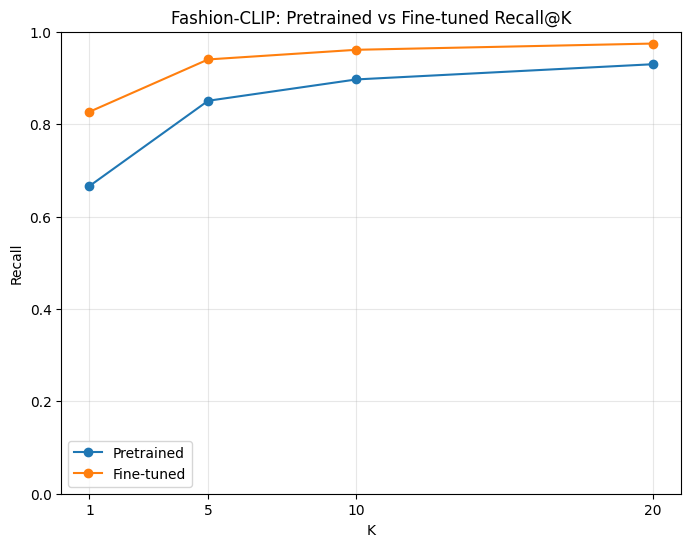

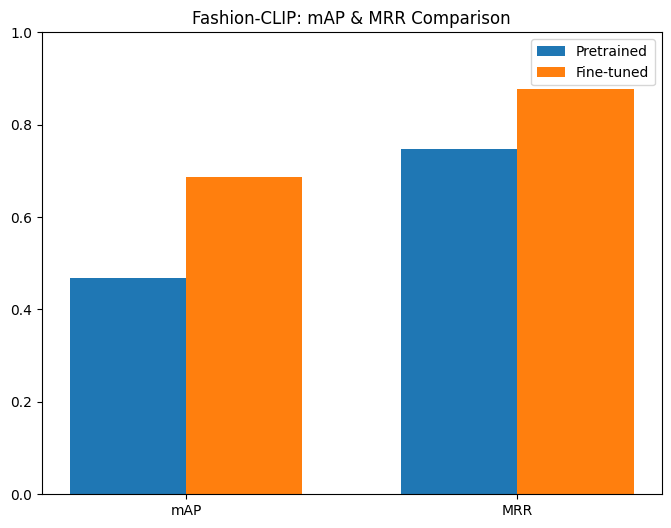

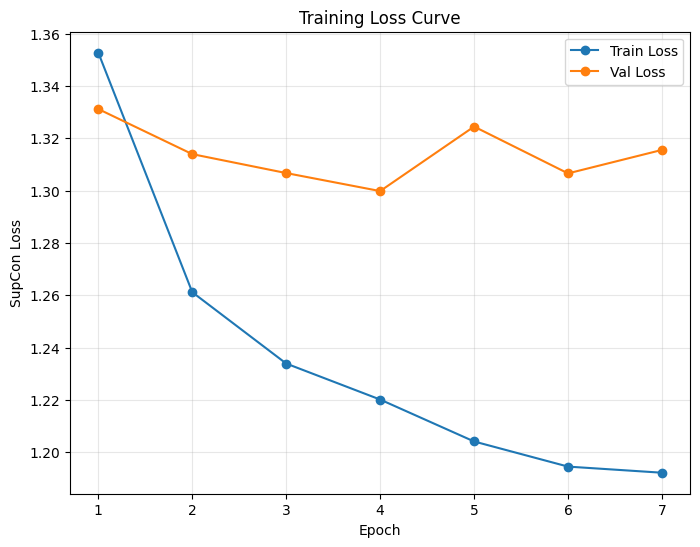

Đã lưu 3 biểu đồ vào: /kaggle/working/visfit_inshop_finetune/plots


In [24]:
fig1, ax1 = plt.subplots(figsize=(8, 6))
k_values = list(CONFIG["KS"])

pretrained_recalls = [pretrained_metrics[f"Recall@{k}"] for k in k_values]
finetuned_recalls = [finetuned_metrics[f"Recall@{k}"] for k in k_values]

ax1.plot(k_values, pretrained_recalls, marker="o", label="Pretrained")
ax1.plot(k_values, finetuned_recalls, marker="o", label="Fine-tuned")
ax1.set_xlabel("K")
ax1.set_ylabel("Recall")
ax1.set_title("Fashion-CLIP: Pretrained vs Fine-tuned Recall@K")
ax1.set_xticks(k_values)
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(True, alpha=0.3)
fig1.savefig(PLOTS_DIR / "recall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
labels = ["mAP", "MRR"]
pretrained_vals = [pretrained_metrics["mAP"], pretrained_metrics["MRR"]]
finetuned_vals = [finetuned_metrics["mAP"], finetuned_metrics["MRR"]]
x = np.arange(len(labels))
width = 0.35
ax2.bar(x - width / 2, pretrained_vals, width, label="Pretrained")
ax2.bar(x + width / 2, finetuned_vals, width, label="Fine-tuned")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylim(0, 1)
ax2.set_title("Fashion-CLIP: mAP & MRR Comparison")
ax2.legend()
fig2.savefig(PLOTS_DIR / "map_mrr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

fig3, ax3 = plt.subplots(figsize=(8, 6))
ax3.plot(training_history_df["epoch"], training_history_df["train_loss"], marker="o", label="Train Loss")
ax3.plot(training_history_df["epoch"], training_history_df["val_loss"], marker="o", label="Val Loss")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("SupCon Loss")
ax3.set_title("Training Loss Curve")
ax3.legend()
ax3.grid(True, alpha=0.3)
fig3.savefig(PLOTS_DIR / "training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu 3 biểu đồ vào:", PLOTS_DIR)

In [25]:
pretrained_top20_df.to_csv(RESULTS_DIR / "pretrained_top20.csv", index=False)
finetuned_top20_df.to_csv(RESULTS_DIR / "finetuned_top20.csv", index=False)
comparison_df.to_csv(RESULTS_DIR / "pretrained_vs_finetuned.csv", index=False)
delta_df.to_csv(RESULTS_DIR / "delta_analysis.csv", index=False)

print("Đã lưu:")
print(" -", RESULTS_DIR / "pretrained_top20.csv")
print(" -", RESULTS_DIR / "finetuned_top20.csv")
print(" -", RESULTS_DIR / "pretrained_vs_finetuned.csv")
print(" -", RESULTS_DIR / "delta_analysis.csv")
print(" -", LOGS_DIR / "training_history.csv", "(đã lưu ở Cell 17)")
print(" -", LOGS_DIR / "config.json", "(đã lưu ở Cell 1)")

Đã lưu:
 - /kaggle/working/visfit_inshop_finetune/results/pretrained_top20.csv
 - /kaggle/working/visfit_inshop_finetune/results/finetuned_top20.csv
 - /kaggle/working/visfit_inshop_finetune/results/pretrained_vs_finetuned.csv
 - /kaggle/working/visfit_inshop_finetune/results/delta_analysis.csv
 - /kaggle/working/visfit_inshop_finetune/logs/training_history.csv (đã lưu ở Cell 17)
 - /kaggle/working/visfit_inshop_finetune/logs/config.json (đã lưu ở Cell 1)


In [26]:
print("=" * 50)
print("SANITY CHECKS")
print("=" * 50)

errors = []

# 1. Train / Query / Gallery item IDs không overlap
train_items_check = set(train_full_df["item_id"])
query_items_check = set(query_df["item_id"])
gallery_items_check = set(gallery_df["item_id"])
if len(train_items_check & query_items_check) > 0:
    errors.append(f"Train và Query có {len(train_items_check & query_items_check)} item_id trùng nhau.")
if len(train_items_check & gallery_items_check) > 0:
    errors.append(f"Train và Gallery có {len(train_items_check & gallery_items_check)} item_id trùng nhau.")

# 2. Query và Gallery không được dùng trong training (kiểm tra train_sub/val_sub chỉ từ train_full_df)
if not set(train_sub_df["item_id"]).issubset(train_items_check):
    errors.append("train_sub_df chứa item_id ngoài train_full_df.")
if not set(val_sub_df["item_id"]).issubset(train_items_check):
    errors.append("val_sub_df chứa item_id ngoài train_full_df.")

# 3. Mỗi query (trong eval set) có positive gallery
n_no_positive = sum(1 for name in eval_query_image_names if len(official_positive_dict[name]) == 0)
if n_no_positive > 0:
    errors.append(f"{n_no_positive} eval query không có positive gallery.")

# 4 & 5. Embedding shape đúng, dimension = 512
for name, emb in [("pretrained_query", pretrained_query_embeddings),
                   ("pretrained_gallery", pretrained_gallery_embeddings),
                   ("finetuned_query", finetuned_query_embeddings),
                   ("finetuned_gallery", finetuned_gallery_embeddings)]:
    if emb.shape[1] != 512:
        errors.append(f"{name} embedding dimension = {emb.shape[1]}, kỳ vọng 512")

# 6 & 7. Không NaN / Inf
for name, emb in [("pretrained_query", pretrained_query_embeddings),
                   ("pretrained_gallery", pretrained_gallery_embeddings),
                   ("finetuned_query", finetuned_query_embeddings),
                   ("finetuned_gallery", finetuned_gallery_embeddings)]:
    if np.isnan(emb).any():
        errors.append(f"{name} embedding chứa NaN")
    if np.isinf(emb).any():
        errors.append(f"{name} embedding chứa Inf")

# 8. Norm ~ 1
for name, emb in [("pretrained_query", pretrained_query_embeddings),
                   ("finetuned_query", finetuned_query_embeddings)]:
    norms = np.linalg.norm(emb, axis=1)
    if abs(norms.mean() - 1.0) > 1e-2:
        errors.append(f"{name} norm mean = {norms.mean():.4f}, lệch quá xa 1.0")

# 9. Metrics trong [0,1]
for metrics_dict, name in [(pretrained_metrics, "Pretrained"), (finetuned_metrics, "Fine-tuned")]:
    for m in metric_names:
        if not (0.0 <= metrics_dict[m] <= 1.0 + 1e-9):
            errors.append(f"[{name}] {m} = {metrics_dict[m]} nằm ngoài [0,1]")

# 10. Recall monotonic
for metrics_dict, name in [(pretrained_metrics, "Pretrained"), (finetuned_metrics, "Fine-tuned")]:
    values = [metrics_dict["Recall@1"], metrics_dict["Recall@5"],
              metrics_dict["Recall@10"], metrics_dict["Recall@20"]]
    if not all(values[i] <= values[i + 1] + 1e-9 for i in range(len(values) - 1)):
        errors.append(f"[{name}] Recall@K không monotonic: {values}")

# 11 & 12. Query/Gallery count pretrained == finetuned
if pretrained_metrics["Queries"] != finetuned_metrics["Queries"]:
    errors.append("Query count pretrained != finetuned")
if pretrained_metrics["Gallery"] != finetuned_metrics["Gallery"]:
    errors.append("Gallery count pretrained != finetuned")

# 13. Ground truth giống nhau (cùng positive_dict được dùng cho cả 2 evaluate_retrieval call)
if len(official_positive_dict) == 0:
    errors.append("official_positive_dict rỗng.")

# 14. FAISS index dimension đúng
if pretrained_metrics["Dimension"] != finetuned_metrics["Dimension"]:
    errors.append("FAISS index dimension khác nhau giữa pretrained và fine-tuned.")

# 15. Best checkpoint tồn tại
if not checkpoint_path.exists():
    errors.append(f"Checkpoint không tồn tại: {checkpoint_path}")

if errors:
    print(f"\n[FAILED] Tìm thấy {len(errors)} lỗi:\n")
    for e in errors:
        print(" -", e)
else:
    print("\n[PASSED] Tất cả 15 sanity check đều hợp lệ.")
print("=" * 50)

SANITY CHECKS

[PASSED] Tất cả 15 sanity check đều hợp lệ.


In [27]:
VISUALIZE_IMAGES = False  # đặt True nếu muốn hiển thị ảnh (làm notebook nặng hơn)

np.random.seed(CONFIG["SEED"])
sample_query_names = np.random.choice(eval_query_image_names, size=5, replace=False)

query_item_id_map = dict(zip(query_df["image_name"], query_df["item_id"]))

for query_image_name in sample_query_names:
    query_item_id = query_item_id_map[query_image_name]
    positives = official_positive_dict[query_image_name]

    print("\n" + "=" * 60)
    print(f"Query image_name : {query_image_name}")
    print(f"Query item_id    : {query_item_id}")
    print(f"\nGround-truth positive gallery ({len(positives)}):")
    for p in sorted(positives):
        print(f"  {p}")

    print(f"\nTop-10 PRETRAINED:")
    rows = pretrained_top20_df[pretrained_top20_df["query_image_name"] == query_image_name].sort_values("rank").head(10)
    for _, r in rows.iterrows():
        marker = " <-- POSITIVE" if r["is_positive"] else ""
        print(f"  rank {r['rank']:2d} | {r['retrieved_image_name']:50s} | item={r['retrieved_item_id']:15s} | "
              f"score={r['similarity_score']:.4f}{marker}")

    print(f"\nTop-10 FINE-TUNED:")
    rows = finetuned_top20_df[finetuned_top20_df["query_image_name"] == query_image_name].sort_values("rank").head(10)
    for _, r in rows.iterrows():
        marker = " <-- POSITIVE" if r["is_positive"] else ""
        print(f"  rank {r['rank']:2d} | {r['retrieved_image_name']:50s} | item={r['retrieved_item_id']:15s} | "
              f"score={r['similarity_score']:.4f}{marker}")

    if VISUALIZE_IMAGES:
        try:
            fig, axes = plt.subplots(1, 6, figsize=(18, 3))
            q_path = resolve_image_path(IMAGE_ROOT, query_image_name)
            axes[0].imshow(Image.open(q_path).convert("RGB"))
            axes[0].set_title("Query")
            axes[0].axis("off")

            top5_finetuned = finetuned_top20_df[
                finetuned_top20_df["query_image_name"] == query_image_name
            ].sort_values("rank").head(5)
            for i, (_, r) in enumerate(top5_finetuned.iterrows()):
                img_path = resolve_image_path(IMAGE_ROOT, r["retrieved_image_name"])
                axes[i + 1].imshow(Image.open(img_path).convert("RGB"))
                color = "green" if r["is_positive"] else "red"
                axes[i + 1].set_title(f"#{i+1}", color=color)
                axes[i + 1].axis("off")
            plt.show()
        except Exception as e:
            print(f"[WARNING] Không thể visualize ảnh: {e}")

    print("-" * 60)


Query image_name : img/WOMEN/Rompers_Jumpsuits/id_00003861/02_4_full.jpg
Query item_id    : id_00003861

Ground-truth positive gallery (2):
  img/WOMEN/Rompers_Jumpsuits/id_00003861/02_1_front.jpg
  img/WOMEN/Rompers_Jumpsuits/id_00003861/02_2_side.jpg

Top-10 PRETRAINED:
  rank  1 | img/WOMEN/Rompers_Jumpsuits/id_00003861/02_1_front.jpg | item=id_00003861     | score=0.9268 <-- POSITIVE
  rank  2 | img/WOMEN/Rompers_Jumpsuits/id_00003861/02_2_side.jpg | item=id_00003861     | score=0.9057 <-- POSITIVE
  rank  3 | img/WOMEN/Rompers_Jumpsuits/id_00001126/05_7_additional.jpg | item=id_00001126     | score=0.8149
  rank  4 | img/WOMEN/Rompers_Jumpsuits/id_00005331/01_2_side.jpg | item=id_00005331     | score=0.8076
  rank  5 | img/WOMEN/Dresses/id_00004651/05_2_side.jpg        | item=id_00004651     | score=0.7921
  rank  6 | img/WOMEN/Rompers_Jumpsuits/id_00006235/01_2_side.jpg | item=id_00006235     | score=0.7914
  rank  7 | img/WOMEN/Rompers_Jumpsuits/id_00003272/01_2_side.jpg | item

In [28]:
delta_map = delta_df.loc[delta_df["Metric"] == "mAP", "Absolute Delta"].values[0]
delta_r1 = delta_df.loc[delta_df["Metric"] == "Recall@1", "Absolute Delta"].values[0]

print("=" * 60)
print("FINAL AUTO SUMMARY")
print("=" * 60)
print()
print(f"Pretrained  - Recall@1: {pretrained_metrics['Recall@1']:.4f} | mAP: {pretrained_metrics['mAP']:.4f} | "
      f"MRR: {pretrained_metrics['MRR']:.4f}")
print(f"Fine-tuned  - Recall@1: {finetuned_metrics['Recall@1']:.4f} | mAP: {finetuned_metrics['mAP']:.4f} | "
      f"MRR: {finetuned_metrics['MRR']:.4f}")
print()

if delta_map > 0.005:
    conclusion = "Fine-tuning trên official In-shop train partition CẢI THIỆN mAP retrieval."
elif delta_map < -0.005:
    conclusion = "Fine-tuning trên official In-shop train partition LÀM GIẢM mAP retrieval."
else:
    conclusion = ("Chênh lệch mAP giữa Pretrained và Fine-tuned rất nhỏ (|delta| <= 0.005) "
                  "- có thể coi là 'difference is small', cần thêm thời gian training hoặc "
                  "kiểm tra thêm trước khi kết luận rõ ràng.")

print(conclusion)
print()
print(f"Delta mAP      = {delta_map:+.4f}")
print(f"Delta Recall@1 = {delta_r1:+.4f}")
print(f"Best checkpoint: {checkpoint_path}")
print(f"Training dừng ở epoch {training_history_df['epoch'].iloc[-1]} "
      f"(best val_loss = {best_val_loss:.4f})")
print()
print("Toàn bộ kết quả chi tiết đã được lưu tại:", OUTPUT_DIR)
print("=" * 60)

FINAL AUTO SUMMARY

Pretrained  - Recall@1: 0.6660 | mAP: 0.4680 | MRR: 0.7482
Fine-tuned  - Recall@1: 0.8267 | mAP: 0.6863 | MRR: 0.8768

Fine-tuning trên official In-shop train partition CẢI THIỆN mAP retrieval.

Delta mAP      = +0.2183
Delta Recall@1 = +0.1607
Best checkpoint: /kaggle/working/visfit_inshop_finetune/checkpoints/best_fashionclip_inshop.pt
Training dừng ở epoch 7 (best val_loss = 1.2998)

Toàn bộ kết quả chi tiết đã được lưu tại: /kaggle/working/visfit_inshop_finetune
